PHASE 1: DATA UNDERSTANDING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/hospital_readmissions_30k.csv")

In [3]:
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [4]:
df.shape

(30000, 12)

In [5]:
df.columns

Index(['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi',
       'diabetes', 'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days'],
      dtype='object')

In [6]:
df.dtypes

patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
readmitted_30_days        object
dtype: object

In [7]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


In [10]:
df["readmitted_30_days"].value_counts()

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64

PHASE 2: EXPLORATORY DATA ANALYSIS

TYPE 1- Univariate Analysis(Analyze one variable)

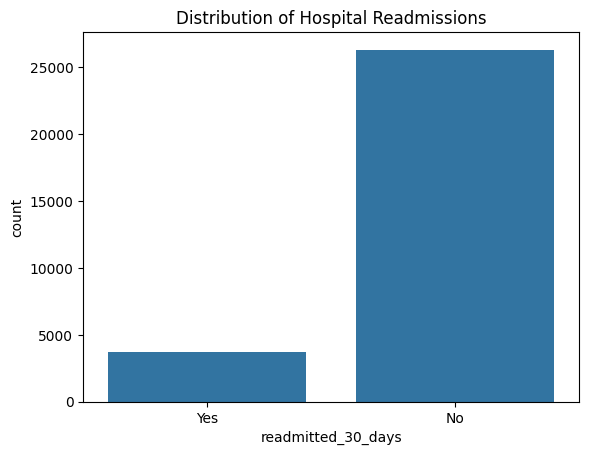

In [11]:
sns.countplot(x="readmitted_30_days", data=df)
plt.title("Distribution of Hospital Readmissions")
plt.show()

The target variable is imbalanced. Most patients were not readmitted within 30 days, while a smaller percentage were readmitted. This imbalance should be considered during model training and evaluation.

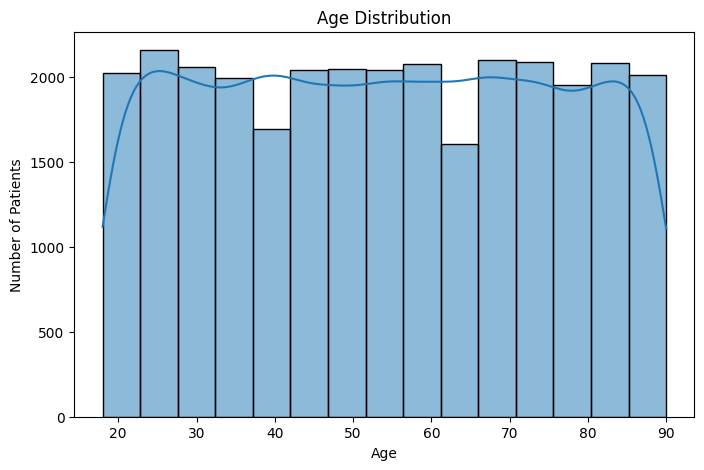

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=15, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

The age distribution is fairly uniform across the range of 18 to 90 years. There are no obvious anomalies or unrealistic values, indicating that the age feature is suitable for model training.

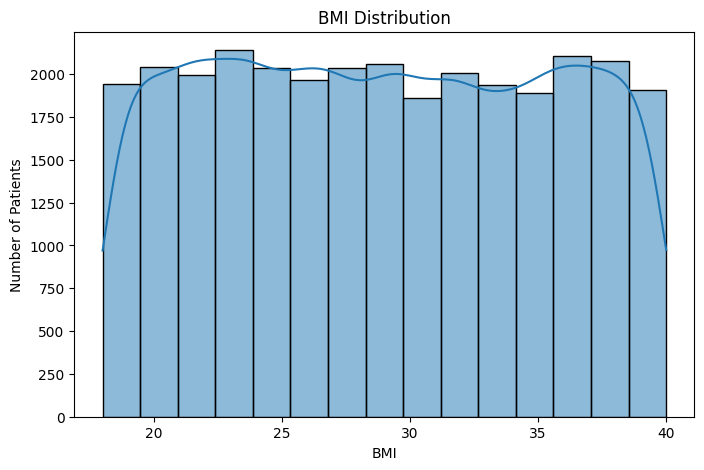

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], bins=15, kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.show()

The BMI values are distributed across the range of 18 to 40 with no obvious anomalies. The feature appears complete and suitable for model training.

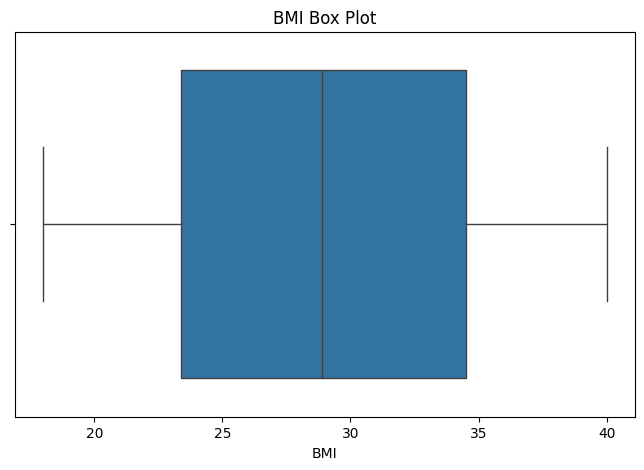

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["bmi"])
plt.title("BMI Box Plot")
plt.xlabel("BMI")
plt.show()

The BMI box plot shows no significant outliers. Most BMI values are concentrated between approximately 23 and 35, with a median around 29. The feature appears suitable for model training without outlier treatment.

TYPE 2-Bivariate Analysis(Analyze the relationship between two variables)



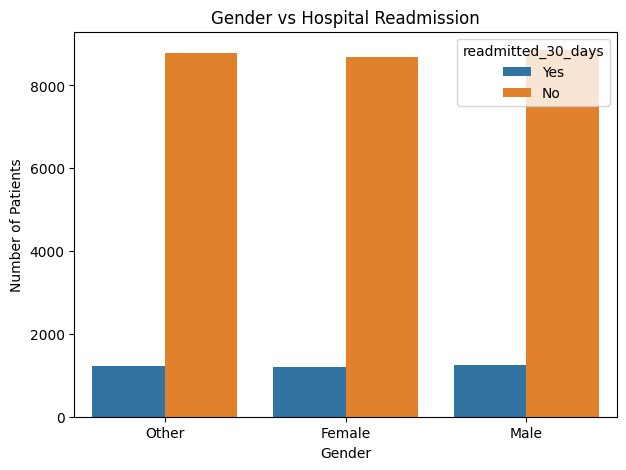

In [15]:
plt.figure(figsize=(7,5))
sns.countplot(x="gender", hue="readmitted_30_days", data=df)
plt.title("Gender vs Hospital Readmission")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

The distribution of hospital readmissions appears similar across male, female, and other gender categories. Based on this visualization, gender does not show a strong visual relationship with hospital readmission.

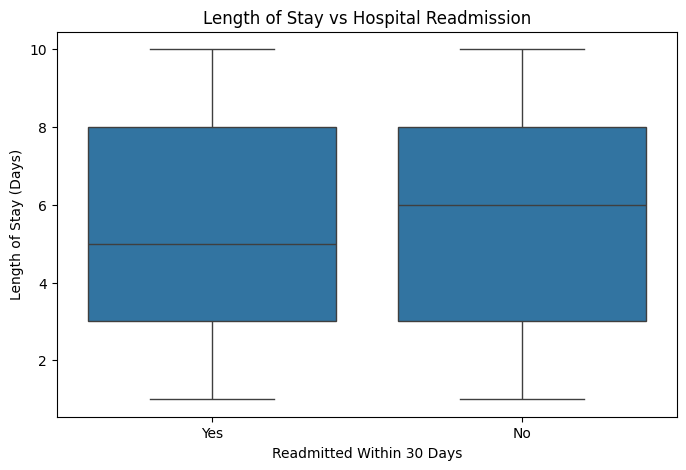

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x="readmitted_30_days", y="length_of_stay", data=df)
plt.title("Length of Stay vs Hospital Readmission")
plt.xlabel("Readmitted Within 30 Days")
plt.ylabel("Length of Stay (Days)")
plt.show()

The length of hospital stay shows a similar distribution for both readmitted and non-readmitted patients. Based on the visualization, there is no strong visual relationship between length of stay and hospital readmission.

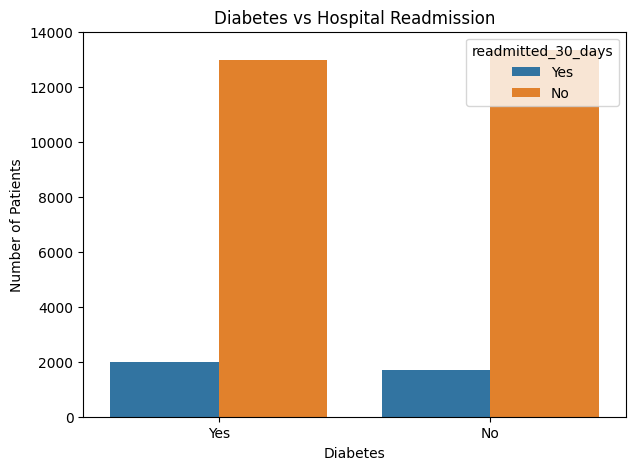

In [17]:
plt.figure(figsize=(7,5))
sns.countplot(x="diabetes", hue="readmitted_30_days", data=df)
plt.title("Diabetes vs Hospital Readmission")
plt.xlabel("Diabetes")
plt.ylabel("Number of Patients")
plt.show()

Patients with and without diabetes both show a similar distribution of readmission outcomes. Based on this count plot alone, there is no strong visual evidence that diabetes is associated with hospital readmission.

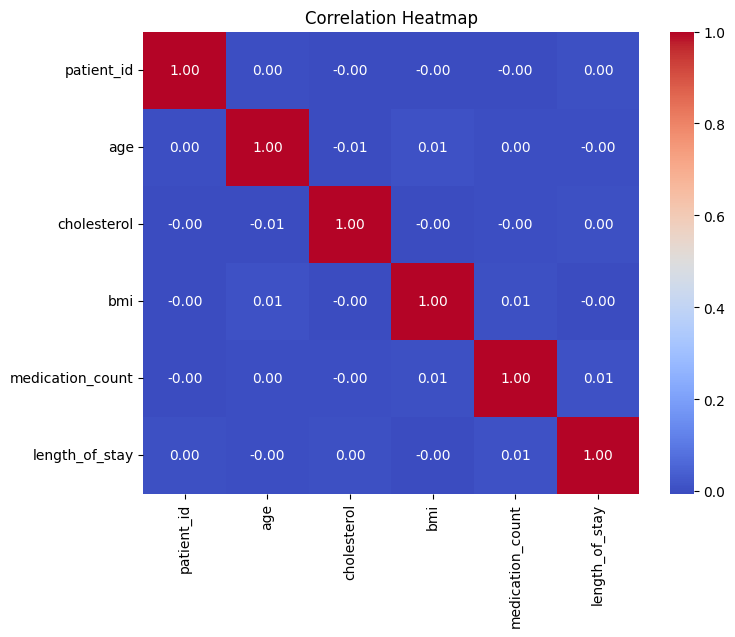

In [18]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

The numerical features show very weak correlations with each other, indicating no significant multicollinearity.

PHASE 3- DATA PREPROCESSING

In [19]:
df.columns

Index(['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi',
       'diabetes', 'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days'],
      dtype='object')

In [20]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]
print(X.shape)
print(y.shape)

(30000, 11)
(30000,)


In [21]:
X.dtypes

patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
dtype: object

In [22]:
X["blood_pressure"].head(10)

0     130/72
1     120/92
2     135/78
3     123/80
4     135/84
5    139/100
6     139/79
7     153/81
8     111/76
9     142/72
Name: blood_pressure, dtype: object

In [23]:
X[["systolic_bp", "diastolic_bp"]] = X["blood_pressure"].str.split("/", expand=True)

In [24]:
X.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,systolic_bp,diastolic_bp
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,130,72
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,120,92
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,135,78
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,123,80
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,135,84


In [25]:
X["systolic_bp"] = X["systolic_bp"].astype(int)
X["diastolic_bp"] = X["diastolic_bp"].astype(int)

In [26]:
X.dtypes

patient_id                 int64
age                        int64
gender                    object
blood_pressure            object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
systolic_bp                int64
diastolic_bp               int64
dtype: object

In [27]:
X = X.drop("blood_pressure", axis=1)

In [28]:
X.columns

Index(['patient_id', 'age', 'gender', 'cholesterol', 'bmi', 'diabetes',
       'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'systolic_bp', 'diastolic_bp'],
      dtype='object')

In [29]:
y = y.map({
    "Yes": 1,
    "No": 0
})

In [30]:
y.head()

0    1
1    0
2    0
3    0
4    0
Name: readmitted_30_days, dtype: int64

In [31]:
X.select_dtypes(include="object").columns

Index(['gender', 'diabetes', 'hypertension', 'discharge_destination'], dtype='object')

In [32]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [33]:
encoded_data = encoder.fit_transform(
    X[["gender", "diabetes", "hypertension", "discharge_destination"]]
)

In [34]:
encoded_columns = encoder.get_feature_names_out(
    ["gender", "diabetes", "hypertension", "discharge_destination"]
)

In [35]:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoded_columns,
    index=X.index
)

In [36]:
encoded_df.head()

,gender_Female,gender_Male,gender_Other,diabetes_No,diabetes_Yes,hypertension_No,hypertension_Yes,discharge_destination_Home,discharge_destination_Nursing_Facility,discharge_destination_Rehab
0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


In [37]:
X = X.drop(
    ["gender", "diabetes", "hypertension", "discharge_destination"],
    axis=1
)

X = pd.concat([X, encoded_df], axis=1)

In [38]:
X.head()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay,systolic_bp,diastolic_bp,gender_Female,gender_Male,gender_Other,diabetes_No,diabetes_Yes,hypertension_No,hypertension_Yes,discharge_destination_Home,discharge_destination_Nursing_Facility,discharge_destination_Rehab
0,1,74,240,31.5,5,1,130,72,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
1,2,46,292,36.3,4,3,120,92,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3,89,153,30.3,1,1,135,78,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,4,84,153,31.5,3,10,123,80,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
4,5,32,205,18.4,6,4,135,84,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0


PHASE 4- TRAIN TEST SPLIT


In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [41]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(24000, 18)
(6000, 18)
(24000,)
(6000,)
